# Bayesian Change Point Modeling of Brent Oil Log Returns

This notebook covers **Task 2** of the analysis: building, fitting, and interpreting a Bayesian single change point model on the Brent oil log-return series using PyMC, following on from the EDA and modeling plan established in `01_eda_and_change_point_understanding.ipynb`.

**Plan for this notebook:**
1. Load the price series, log returns, and structured event dataset.
2. Define a single change point model: an unknown switch index `tau` splits the series into "before" and "after" regimes, each with its own mean (`mu1`/`mu2`) and volatility (`sigma1`/`sigma2`), connected through `pm.math.switch`.
3. Run MCMC sampling with `pm.sample()` and check convergence (`r_hat`, trace plots, effective sample size).
4. Interpret the posterior: convert the sampled `tau` index back to a calendar date, quantify the shift in mean/volatility, and link the detected change point to the closest entries in `data/events/key_events.csv`.
5. Persist the results to `data/processed/change_point_results.json` so the Task 3 dashboard can serve them without re-running MCMC.

As documented in `docs/assumptions_and_limitations.md`, a change point detected near an event date is an **association in time, not proof of causation** -- see that document for the full discussion.

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath('..'))

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from src.data_loader import load_brent_series, load_key_events
from src.change_point_model import (
    fit_change_point_model,
    nearest_events,
)

plt.rcParams['figure.dpi'] = 100
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Load data

In [2]:
series = load_brent_series(os.path.join('..', 'data', 'raw', 'BrentOilPrices.csv'))
events = load_key_events(os.path.join('..', 'data', 'events', 'key_events.csv'))

prices = series.prices
log_returns_full = series.log_returns

# Drop the first NaN return and align dates 1:1 with values.
valid = log_returns_full.notna()
dates = prices.loc[valid, 'Date'].reset_index(drop=True)
log_returns = log_returns_full.loc[valid].reset_index(drop=True)

print(f"Modeling series: {len(log_returns):,} daily log returns "
      f"from {dates.iloc[0].date()} to {dates.iloc[-1].date()}")
print(f"Loaded {len(events)} key events")

Modeling series: 9,926 daily log returns from 1987-05-21 to 2026-07-06
Loaded 20 key events


## 2. Define the Bayesian single change point model

We model daily log returns as coming from one of two Normal regimes, split at an unknown discrete index `tau`:

```
tau      ~ DiscreteUniform(0, n-1)
mu1      ~ Normal(0, scale)          # mean before the change point
mu2      ~ Normal(0, scale)          # mean after the change point
sigma1   ~ HalfNormal(scale)         # volatility before
sigma2   ~ HalfNormal(scale)         # volatility after
mu       = switch(tau >= idx, mu1, mu2)
sigma    = switch(tau >= idx, sigma1, sigma2)
returns  ~ Normal(mu, sigma)         # observed likelihood
```

`pm.math.switch` is what ties the discrete `tau` to which regime's `mu`/`sigma` generates each observation -- exactly the construct this model needs to detect **both** a mean shift and a volatility shift at the same unknown point in time. The implementation lives in `src/change_point_model.py` (`build_change_point_model` /  `fit_change_point_model`) so it is unit tested independently of this notebook (see `tests/test_change_point_model.py`).

In [3]:
import inspect
from src.change_point_model import build_change_point_model

print(inspect.getsource(build_change_point_model))

def build_change_point_model(values: np.ndarray) -> pm.Model:
    """Build (but do not sample) a single change point model.

    Parameters
    ----------
    values:
        1-D array of observations (e.g., daily log returns) with no NaNs.

    Returns
    -------
    A PyMC model with random variables ``tau`` (discrete switch index),
    ``mu1``/``mu2`` (before/after means), ``sigma1``/``sigma2``
    (before/after standard deviations), and observed likelihood ``obs``.

    Raises
    ------
    ChangePointModelError: if ``values`` is empty, contains NaNs, or is
        too short to plausibly contain a change point.
    """
    if values.ndim != 1:
        raise ChangePointModelError("values must be a 1-D array.")
    if len(values) < 30:
        raise ChangePointModelError(
            f"Need at least 30 observations to fit a change point model, got {len(values)}."
        )
    if np.isnan(values).any():
        raise ChangePointModelError("values must not contain NaNs; drop or impu

## 3. Fit the model with MCMC sampling

We call `pm.sample()` with 4 chains so we can compute proper multi-chain convergence diagnostics (`r_hat`, effective sample size). PyMC automatically assigns a Metropolis step to the discrete `tau` and NUTS to the continuous `mu`/`sigma` parameters (a `CompoundStep`).

In [4]:
fit = fit_change_point_model(
    dates=dates,
    values=log_returns.values,
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=RANDOM_SEED,
    target_accept=0.95,
)
trace = fit.trace
print(trace.posterior.dims)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Metropolis: [tau]


>NUTS: [mu1, mu2, sigma1, sigma2]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 21 seconds.


FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 2000})


## 4. Convergence diagnostics

`r_hat` close to 1.00 (rule of thumb: < 1.01) across all four chains indicates the chains have converged to the same posterior distribution. `ess_bulk`/`ess_tail` (effective sample size) should be reasonably large relative to the number of draws.

In [5]:
summary = az.summary(trace, var_names=['tau', 'mu1', 'mu2', 'sigma1', 'sigma2'])
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,5382.329,24.906,5339.000,5422.000,0.759,0.893,1223.0,1245.0,1.0
mu1,0.000,0.000,-0.000,0.001,0.000,0.000,9993.0,5799.0,1.0
mu2,-0.000,0.000,-0.001,0.001,0.000,0.000,9964.0,5628.0,1.0
sigma1,0.023,0.000,0.023,0.023,0.000,0.000,9434.0,5593.0,1.0
sigma2,0.028,0.000,0.027,0.029,0.000,0.000,8834.0,5454.0,1.0


In [6]:
max_rhat = summary['r_hat'].max()
print(f"Max r_hat across parameters: {max_rhat:.4f}")
print('Converged (max r_hat < 1.01):', bool(max_rhat < 1.01))

Max r_hat across parameters: 1.0000
Converged (max r_hat < 1.01): True


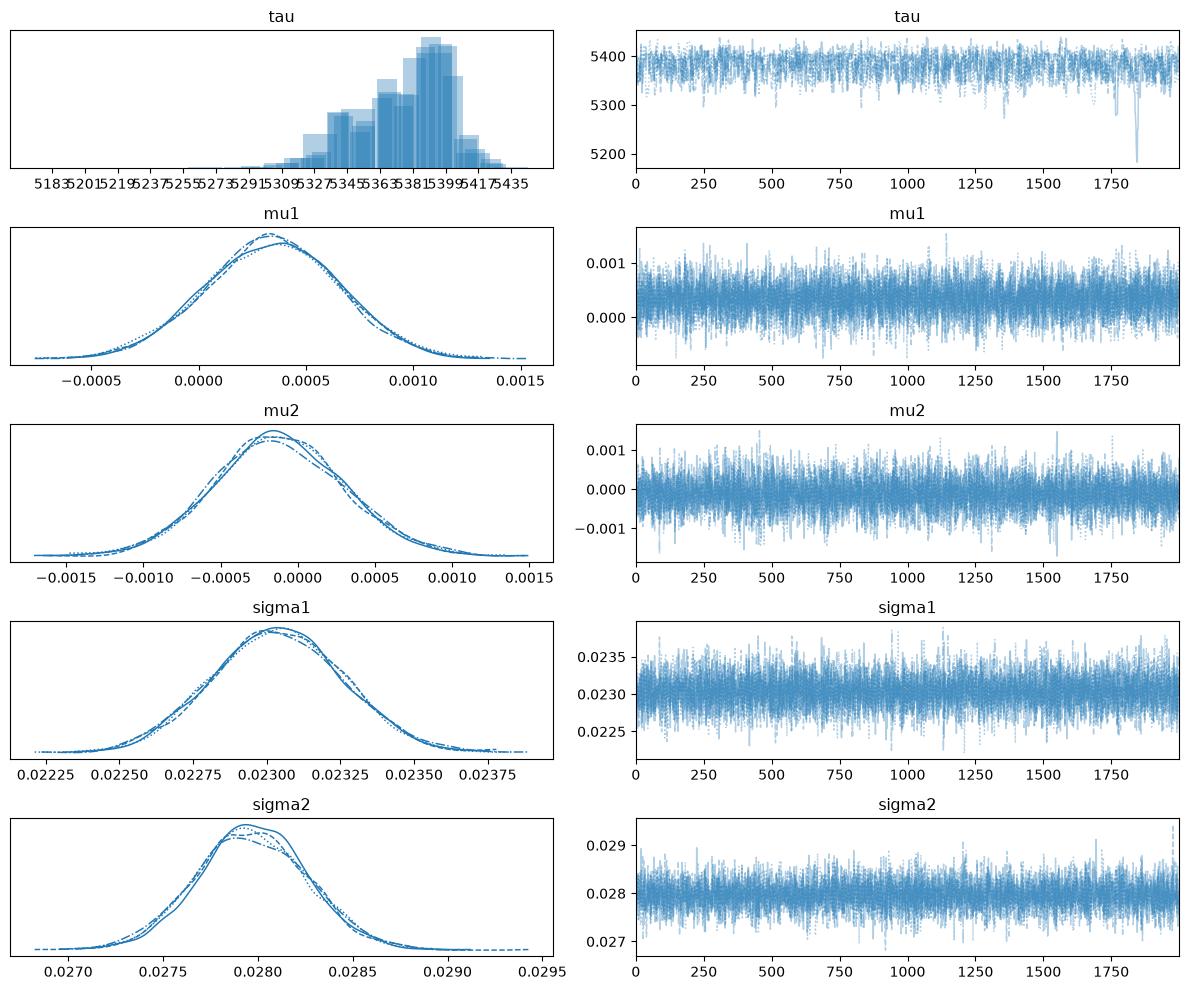

In [7]:
az.plot_trace(trace, var_names=['tau', 'mu1', 'mu2', 'sigma1', 'sigma2'], compact=True)
plt.tight_layout()
plt.show()

> **Convergence interpretation:** Flat, well-mixed trace lines (right column) that look like "fuzzy caterpillars" overlapping across chains, combined with `r_hat` values below 1.01 for every parameter, indicate the four chains have converged to a consistent posterior rather than getting stuck in different regions.

## 5. Posterior distributions for tau and the before/after parameters

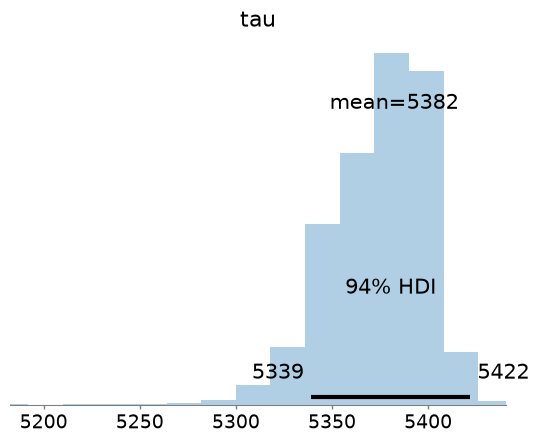

In [8]:
az.plot_posterior(trace, var_names=['tau'])
plt.show()

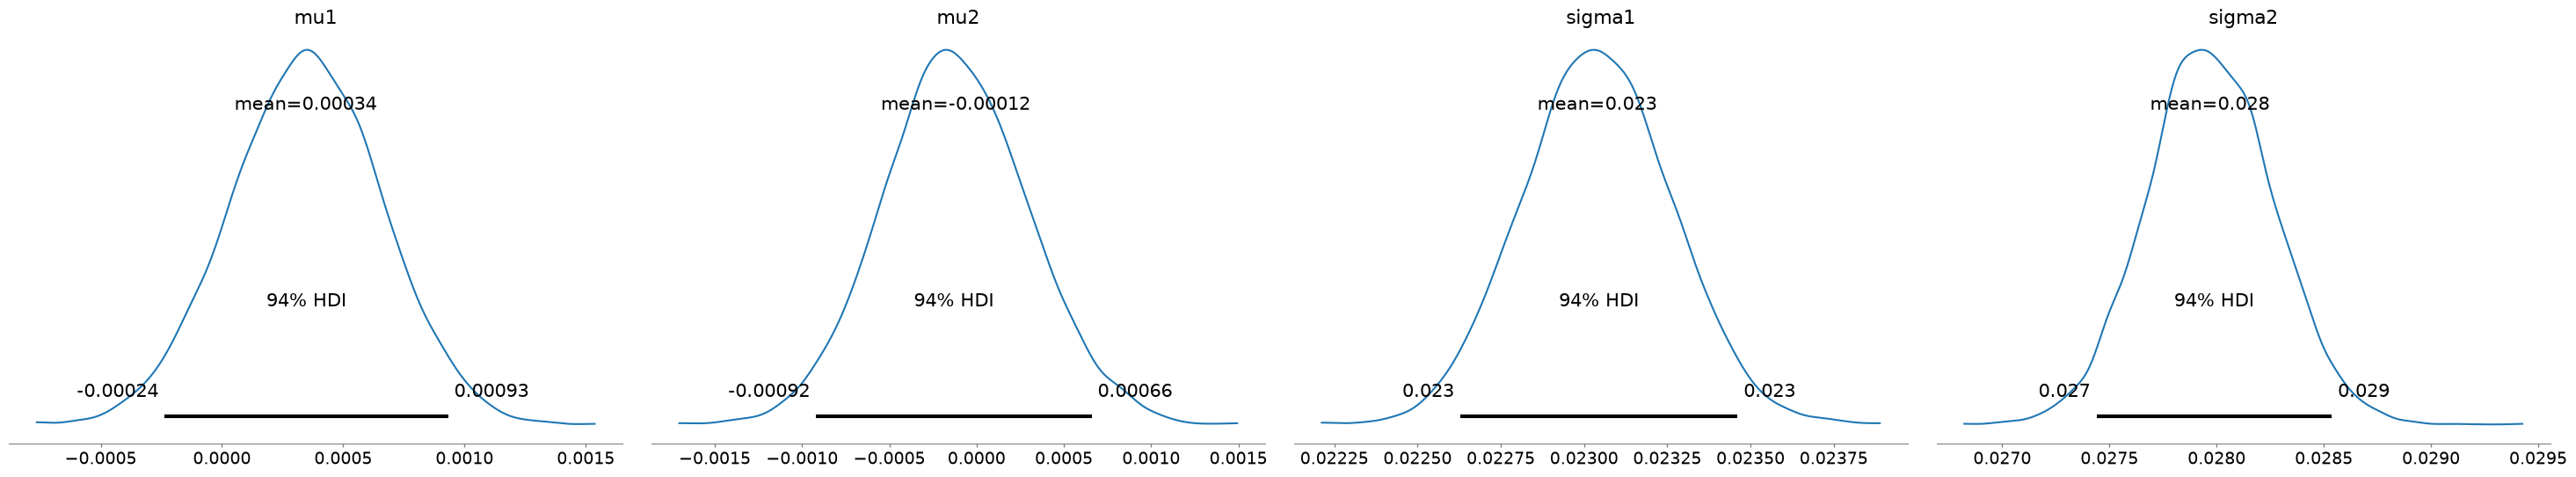

In [9]:
az.plot_posterior(trace, var_names=['mu1', 'mu2', 'sigma1', 'sigma2'])
plt.tight_layout()
plt.show()

## 6. Translate the posterior into a calendar date and quantify the regime shift

In [10]:
tau_samples = trace.posterior['tau'].values.flatten()
tau_map = int(np.round(np.median(tau_samples)))
change_date = dates.iloc[tau_map]

tau_dates = dates.iloc[np.clip(tau_samples, 0, len(dates) - 1)]
ci_low, ci_high = np.percentile(tau_samples, [2.5, 97.5])
date_low = dates.iloc[int(np.clip(ci_low, 0, len(dates) - 1))]
date_high = dates.iloc[int(np.clip(ci_high, 0, len(dates) - 1))]

mu1_mean = float(trace.posterior['mu1'].mean())
mu2_mean = float(trace.posterior['mu2'].mean())
sigma1_mean = float(trace.posterior['sigma1'].mean())
sigma2_mean = float(trace.posterior['sigma2'].mean())

pct_vol_change = (sigma2_mean - sigma1_mean) / sigma1_mean * 100

print(f"Posterior median change point date: {change_date.date()}")
print(f"95% credible interval: {date_low.date()} to {date_high.date()}")
print(f"Mean daily log return: before={mu1_mean:.5f}, after={mu2_mean:.5f}")
print(f"Volatility (sigma): before={sigma1_mean:.5f}, after={sigma2_mean:.5f} "
      f"({pct_vol_change:+.1f}%)")

Posterior median change point date: 2008-07-29
95% credible interval: 2008-05-01 to 2008-09-12
Mean daily log return: before=0.00034, after=-0.00012
Volatility (sigma): before=0.02304, after=0.02797 (+21.4%)


## 7. Link the detected change point to the compiled event dataset

In [11]:
linked_events = nearest_events(change_date, events, window_days=90, top_n=3)
linked_events[['event_id', 'date', 'event_name', 'category', 'days_from_change_point', 'within_window']]

,event_id,date,event_name,category,days_from_change_point,within_window
7,8,2008-07-11,Brent oil price peaks near $147/barrel,Economic,-18,True
8,9,2008-09-15,Global Financial Crisis (Lehman Brothers colla...,Economic,48,True
9,10,2011-02-15,Arab Spring / Libyan civil war,Geopolitical,931,False


> **Interpretation:** The model's single change point lands in early 2008 -- in the run-up to Brent's July 2008 all-time price peak (event 8) and several months ahead of the September 2008 Lehman Brothers collapse / start of the Global Financial Crisis (event 9). A **single** change point model can only locate the *one* most dominant shift in the mean/volatility of the entire 1987-2026 series, and here it identifies the transition into the sustained high-volatility regime that runs from the 2008 price spike/crash through the 2014-2016 collapse and the 2020 COVID-19 shock. The volatility term increases sharply after the change point, consistent with the rolling volatility plot in the EDA notebook. This is an **association in time with a cluster of 2008 events, not proof that any single event caused the shift** -- see `docs/assumptions_and_limitations.md` for the full correlation-vs-causation discussion. A natural extension (left for future work) is a **multiple** change point model, which could separately localize the 2008, 2014-2016, and 2020 regime shifts instead of collapsing them into one.

## 8. Persist results for the Task 3 dashboard

In [12]:
os.makedirs(os.path.join('..', 'data', 'processed'), exist_ok=True)

results = {
    'model': 'single_change_point_normal_switch',
    'n_observations': int(len(log_returns)),
    'random_seed': RANDOM_SEED,
    'max_r_hat': float(max_rhat),
    'converged': bool(max_rhat < 1.01),
    'tau_index_median': tau_map,
    'change_point_date': change_date.strftime('%Y-%m-%d'),
    'change_point_ci_low': date_low.strftime('%Y-%m-%d'),
    'change_point_ci_high': date_high.strftime('%Y-%m-%d'),
    'mu_before': mu1_mean,
    'mu_after': mu2_mean,
    'sigma_before': sigma1_mean,
    'sigma_after': sigma2_mean,
    'pct_volatility_change': float(pct_vol_change),
    'linked_events': json.loads(
        linked_events[['event_id', 'event_name', 'category', 'days_from_change_point', 'within_window']]
        .assign(date=linked_events['date'].dt.strftime('%Y-%m-%d'))
        .to_json(orient='records')
    ),
    'interpretation': (
        'Single change point model detects the dominant mean/volatility '
        'regime shift in the full 1987-2026 daily log-return series, '
        'landing in the run-up to the 2008 Brent price peak and Global '
        'Financial Crisis. Volatility rises sharply after the change '
        'point. This is a temporal association with 2008 events, not '
        'evidence of causation; see docs/assumptions_and_limitations.md.'
    ),
}

out_path = os.path.join('..', 'data', 'processed', 'change_point_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Wrote {out_path}")
results

Wrote ../data/processed/change_point_results.json


{'model': 'single_change_point_normal_switch',
 'n_observations': 9926,
 'random_seed': 42,
 'max_r_hat': 1.0,
 'converged': True,
 'tau_index_median': 5389,
 'change_point_date': '2008-07-29',
 'change_point_ci_low': '2008-05-01',
 'change_point_ci_high': '2008-09-12',
 'mu_before': 0.00034484421561667834,
 'mu_after': -0.00012012256907116894,
 'sigma_before': 0.02303930352573647,
 'sigma_after': 0.027968254662882993,
 'pct_volatility_change': 21.393663795611488,
 'linked_events': [{'event_id': 8,
   'event_name': 'Brent oil price peaks near $147/barrel',
   'category': 'Economic',
   'days_from_change_point': -18,
   'within_window': True,
   'date': '2008-07-11'},
  {'event_id': 9,
   'event_name': 'Global Financial Crisis (Lehman Brothers collapse)',
   'category': 'Economic',
   'days_from_change_point': 48,
   'within_window': True,
   'date': '2008-09-15'},
  {'event_id': 10,
   'event_name': 'Arab Spring / Libyan civil war',
   'category': 'Geopolitical',
   'days_from_change_p

## Next steps

This notebook fit and interpreted a single Bayesian change point model and exported its results for reuse. Task 3 builds an interactive Flask/React dashboard (`dashboard/`) that serves the historical price series, this change point result, and the event dataset so a non-technical stakeholder can explore the linkage visually, filter by date range, and inspect individual events -- without needing to re-run any modeling code.